<a href="https://colab.research.google.com/github/GodishalaAshwith/DeepLearning/blob/main/DL_Intel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading Dataset

In [5]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [6]:
train_dir = "/kaggle/input/intel-image-classification/seg_train/seg_train"
val_dir = "/kaggle/input/intel-image-classification/seg_test/seg_test"
pred_dir = "/kaggle/input/intel-image-classification/seg_pred/seg_pred"

In [7]:
import os

print(os.listdir(train_dir))  # should show 6 classes

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

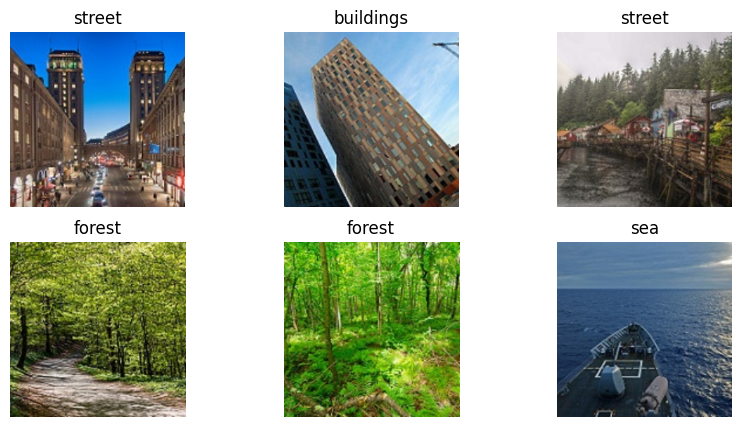

In [14]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(train_data.classes[labels[i]])
    plt.axis('off')

plt.show()

# Loading Data

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform_mlp = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=transform_mlp)
val_data = datasets.ImageFolder(val_dir, transform=transform_mlp)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
transform_cnn = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=transform_cnn)
val_data = datasets.ImageFolder(val_dir, transform=transform_cnn)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

# MLP Model

In [17]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*64*3, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [18]:
def train_model(model, optimizer, epochs=5):
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = 100 * correct / total
        train_losses.append(total_loss)
        val_accs.append(acc)

        print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Acc: {acc:.2f}%")

    return train_losses, val_accs

# Learning Rate


Training with LR=0.1
Epoch 1 | Loss: 793.67 | Acc: 15.83%
Epoch 2 | Loss: 786.46 | Acc: 18.43%
Epoch 3 | Loss: 786.26 | Acc: 17.50%
Epoch 4 | Loss: 784.87 | Acc: 17.50%
Epoch 5 | Loss: 786.52 | Acc: 17.57%

Training with LR=0.01
Epoch 1 | Loss: 626.33 | Acc: 43.90%
Epoch 2 | Loss: 552.14 | Acc: 51.37%
Epoch 3 | Loss: 522.80 | Acc: 54.00%
Epoch 4 | Loss: 505.98 | Acc: 53.87%
Epoch 5 | Loss: 490.97 | Acc: 52.17%

Training with LR=0.001
Epoch 1 | Loss: 713.50 | Acc: 41.70%
Epoch 2 | Loss: 639.17 | Acc: 48.57%
Epoch 3 | Loss: 605.09 | Acc: 49.03%
Epoch 4 | Loss: 586.57 | Acc: 50.23%
Epoch 5 | Loss: 574.86 | Acc: 50.17%


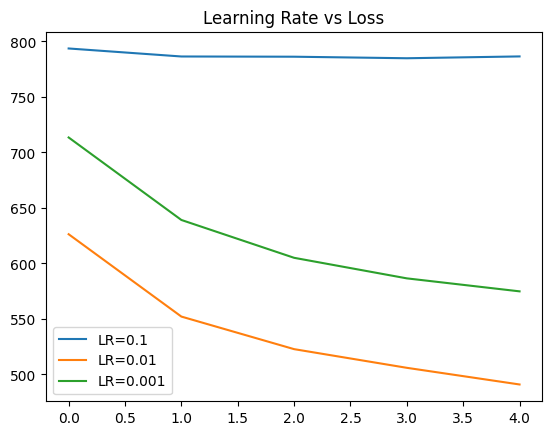

In [19]:
lrs = [0.1, 0.01, 0.001]
all_losses = []

for lr in lrs:
    print(f"\nTraining with LR={lr}")
    model = MLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses, _ = train_model(model, optimizer)
    all_losses.append(losses)

# Plot
for i, lr in enumerate(lrs):
    plt.plot(all_losses[i], label=f"LR={lr}")

plt.legend()
plt.title("Learning Rate vs Loss")
plt.show()

# Optimizer Comparison


Training with SGD
Epoch 1 | Loss: 625.18 | Acc: 47.43%
Epoch 2 | Loss: 554.90 | Acc: 49.80%
Epoch 3 | Loss: 527.21 | Acc: 48.67%
Epoch 4 | Loss: 506.24 | Acc: 53.27%
Epoch 5 | Loss: 493.11 | Acc: 53.47%

Training with Momentum
Epoch 1 | Loss: 637.35 | Acc: 40.53%
Epoch 2 | Loss: 615.70 | Acc: 35.60%
Epoch 3 | Loss: 611.81 | Acc: 44.70%
Epoch 4 | Loss: 601.02 | Acc: 33.97%
Epoch 5 | Loss: 617.64 | Acc: 31.83%

Training with Adam
Epoch 1 | Loss: 648.83 | Acc: 50.60%
Epoch 2 | Loss: 548.23 | Acc: 51.60%
Epoch 3 | Loss: 532.12 | Acc: 52.63%
Epoch 4 | Loss: 508.99 | Acc: 56.17%
Epoch 5 | Loss: 494.77 | Acc: 55.10%

Training with RMSProp
Epoch 1 | Loss: 1207.69 | Acc: 46.20%
Epoch 2 | Loss: 580.85 | Acc: 51.37%
Epoch 3 | Loss: 551.60 | Acc: 51.60%
Epoch 4 | Loss: 531.58 | Acc: 52.83%
Epoch 5 | Loss: 518.36 | Acc: 50.23%


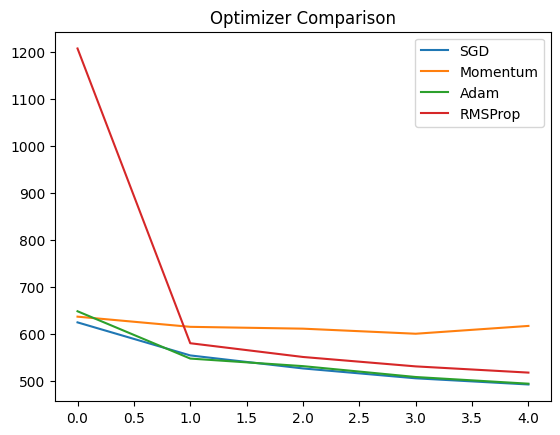

In [20]:
optimizers = {
    "SGD": optim.SGD,
    "Momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam": optim.Adam,
    "RMSProp": optim.RMSprop
}

results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")
    model = MLP().to(device)

    if name == "Momentum":
        optimizer = opt(model.parameters())
    elif name == "SGD":
        optimizer = opt(model.parameters(), lr=0.01)
    else:
        optimizer = opt(model.parameters(), lr=0.001)

    losses, _ = train_model(model, optimizer)
    results[name] = losses

# Plot
for name in results:
    plt.plot(results[name], label=name)

plt.legend()
plt.title("Optimizer Comparison")
plt.show()

# Regularization

In [21]:
class MLP_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*64*3, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("\nWithout Regularization")
model1 = MLP().to(device)
train_model(model1, optim.SGD(model1.parameters(), lr=0.01))

print("\nWith Regularization")
model2 = MLP_Reg().to(device)
train_model(model2, optim.SGD(model2.parameters(), lr=0.01, weight_decay=0.001))


Without Regularization
Epoch 1 | Loss: 624.23 | Acc: 45.87%
Epoch 2 | Loss: 557.20 | Acc: 53.50%
Epoch 3 | Loss: 528.93 | Acc: 50.87%
Epoch 4 | Loss: 510.19 | Acc: 53.33%
Epoch 5 | Loss: 495.64 | Acc: 50.53%

With Regularization
Epoch 1 | Loss: 652.63 | Acc: 40.33%
Epoch 2 | Loss: 584.57 | Acc: 50.83%
Epoch 3 | Loss: 559.82 | Acc: 51.30%
Epoch 4 | Loss: 542.95 | Acc: 49.17%
Epoch 5 | Loss: 532.74 | Acc: 53.40%


([652.627249956131,
  584.5684428811073,
  559.8162758350372,
  542.9540886878967,
  532.7441683411598],
 [40.333333333333336, 50.833333333333336, 51.3, 49.166666666666664, 53.4])

# CNN

In [22]:
transform_cnn = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform_cnn)
val_data = datasets.ImageFolder(val_dir, transform=transform_cnn)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

num_classes = len(train_data.classes)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*56*56,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        return self.fc(self.conv(x))

model = CNN().to(device)
train_model(model, optim.Adam(model.parameters(), lr=0.001))

Epoch 1 | Loss: 437.80 | Acc: 69.30%
Epoch 2 | Loss: 304.18 | Acc: 74.67%
Epoch 3 | Loss: 214.59 | Acc: 71.57%
Epoch 4 | Loss: 125.42 | Acc: 75.97%
Epoch 5 | Loss: 63.52 | Acc: 73.67%


([437.7991176247597,
  304.1801145672798,
  214.59490130841732,
  125.42230343818665,
  63.52363180182874],
 [69.3,
  74.66666666666667,
  71.56666666666666,
  75.96666666666667,
  73.66666666666667])

# ResNet

In [23]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

train_model(model, optim.Adam(model.parameters(), lr=0.0001))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.8MB/s]


Epoch 1 | Loss: 126.83 | Acc: 92.40%
Epoch 2 | Loss: 58.27 | Acc: 92.73%
Epoch 3 | Loss: 28.63 | Acc: 91.40%
Epoch 4 | Loss: 21.49 | Acc: 93.17%
Epoch 5 | Loss: 15.82 | Acc: 93.17%


([126.83322754874825,
  58.274447195231915,
  28.631852724123746,
  21.493679146282375,
  15.817471141228452],
 [92.4, 92.73333333333333, 91.4, 93.16666666666667, 93.16666666666667])

# VGG

In [24]:
model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

train_model(model, optim.Adam(model.parameters(), lr=0.0001))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 102MB/s]


Epoch 1 | Loss: 146.34 | Acc: 91.03%
Epoch 2 | Loss: 92.26 | Acc: 92.20%
Epoch 3 | Loss: 66.44 | Acc: 90.77%
Epoch 4 | Loss: 52.20 | Acc: 91.30%
Epoch 5 | Loss: 40.94 | Acc: 91.03%


([146.34324940294027,
  92.26222018525004,
  66.43793165218085,
  52.195043514017016,
  40.94159702514298],
 [91.03333333333333, 92.2, 90.76666666666667, 91.3, 91.03333333333333])

# Feature Map Visualization

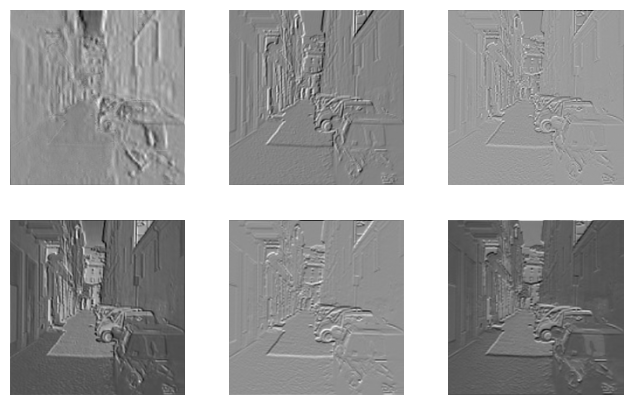

In [25]:
images, _ = next(iter(train_loader))
image = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap = model.features[0](image)

fmap = fmap.cpu().squeeze()

plt.figure(figsize=(8,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(fmap[i], cmap='gray')
    plt.axis('off')

plt.show()

# Autoencoder

In [12]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*3,256),
            nn.ReLU(),
            nn.Linear(256,64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64,256),
            nn.ReLU(),
            nn.Linear(256,64*64*3),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1,3,64,64)

# Re-initialize train_loader and val_loader with the correct transform for AutoEncoder
train_data = datasets.ImageFolder(train_dir, transform=transform_mlp)
val_data = datasets.ImageFolder(val_dir, transform=transform_mlp)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(5):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss:.2f}")

Epoch 1: 13.61
Epoch 2: 8.71
Epoch 3: 8.26
Epoch 4: 8.00
Epoch 5: 7.86


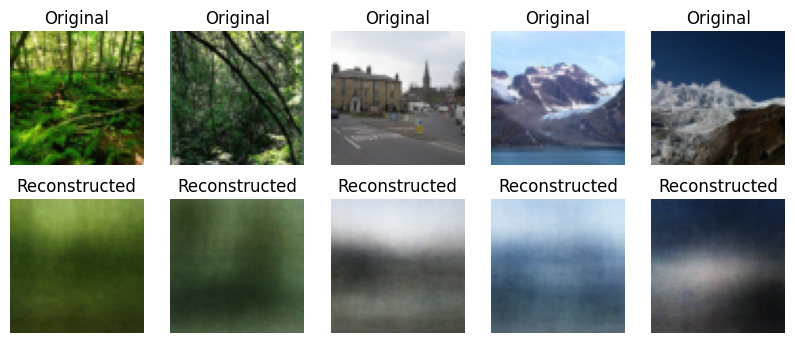

In [13]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

images = images.cpu()
outputs = outputs.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    # original
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    # reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].permute(1,2,0))
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()